# Emergence of Segmentation with Minimalistic White-Box Transformers

Official demo for visualizing attention maps for supervised CRATE.(Read Only)
* Github: https://github.com/Ma-Lab-Berkeley/CRATE
* Arxiv: https://arxiv.org/abs/2308.16271

## Guidlines:
* Download this notebook and upload it to your own colab(optional)
* Setup colab gpu: Edit -> Notebook settings-> T4 GPU -> Save
* Run the notebook!


In [ ]:
# dependencies
! pip install einops
! pip install gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 733.1 kB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

ModuleNotFoundError: No module named 'google'

In [ ]:
%cd drive/MyDrive

/content/drive/MyDrive


In [ ]:
# Downloading checkpoints
!gdown --id 1Y_luqem0JacYwzOYQ9Ke9HZa634n-6zp

In [ ]:
!git clone https://github.com/LeslieTrue/crate-emergence-notebooks.git

In [ ]:
import sys
# modify the path if it's not your directory
sys.path.append('/content/drive/MyDrive/crate-emergence-notebooks')
import torch
import crate
import os
import sys
import argparse
import cv2
import random
import colorsys
import requests
from io import BytesIO
from tqdm import tqdm
import skimage.io
from skimage.measure import find_contours
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms as pth_transforms
import numpy as np
from PIL import Image

In [ ]:
device = 'cuda'

## Define a CRATE model


In [ ]:
url = '/content/drive/MyDrive/crate-demo.pth'
model = crate.CRATEFeat(feat_dim = 768, crate_arch = 'demo',pretrained_path = url, device = device)

Loading weight from /content/drive/MyDrive/crate-demo.pth


## Extract attention maps


In [ ]:
def collect_attention_maps(img_dir, image_size, patch_size, layer):
  img_list = sorted(os.listdir(img_dir))
  attn_list = []
  resized_images = []
  for img_name in tqdm(img_list):
    img_path = os.path.join(img_dir, img_name)
    with open(img_path, 'rb') as f:
      img = Image.open(f)
      img = img.convert('RGB')
    transform = pth_transforms.Compose([
        pth_transforms.Resize((image_size, image_size)),
        pth_transforms.ToTensor(),
        pth_transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    img = transform(img)
    w, h = img.shape[1] - img.shape[1] % patch_size, img.shape[2] - img.shape[2] % patch_size
    img = img[:, :w, :h].unsqueeze(0)
    w_featmap = img.shape[-2] // patch_size
    h_featmap = img.shape[-1] // patch_size

    attentions = model.forward_attn(img.to(device), layer=layer)
    nh = attentions.shape[1]
    attentions = attentions[0, :, 0, 1:].reshape(nh, -1)
    attentions = attentions.reshape(nh, w_featmap, h_featmap)
    attentions = nn.functional.interpolate(attentions.unsqueeze(0), scale_factor=patch_size, mode="nearest")[0].cpu().numpy()
    attn_list.append(attentions)
    resized_images.append(torchvision.utils.make_grid(img, normalize=True, scale_each=True).permute(1, 2, 0))
  return attn_list, resized_images

## Visualizing attention maps
In this section, we visualize the **self-attention maps** from a **supervised CRATE** with 8 × 8 patches trained using classification. The
CRATE architecture automatically learns to perform object segmentation without a complex self-supervised
training recipe or any fine-tuning with segmentation-related annotations. In each row, we visualize all 6 heads for the image. \\
For more visualizations, please refer to Figure 1, Figure 8 and Figure 14 in the paper.

In [ ]:
# modify the path if it's not your directory
img_dir = '/content/drive/MyDrive/crate-emergence-notebooks/demo'
image_size = 480
patch_size = 8
layer = 10

100%|██████████| 8/8 [00:05<00:00,  1.57it/s]


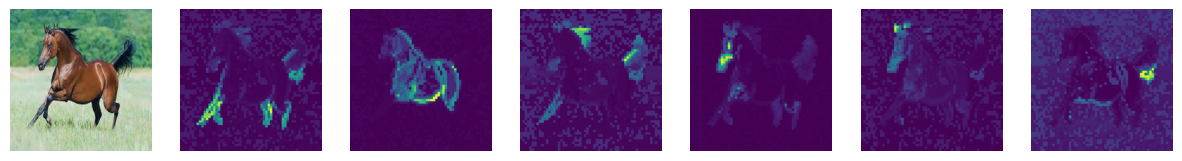

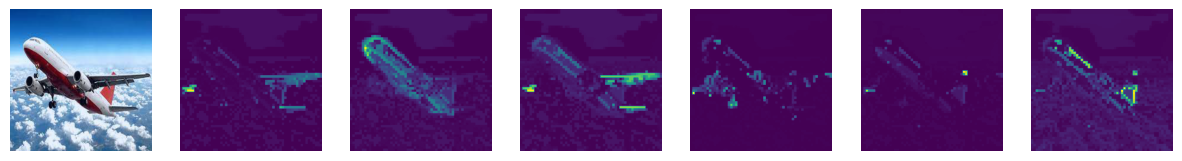

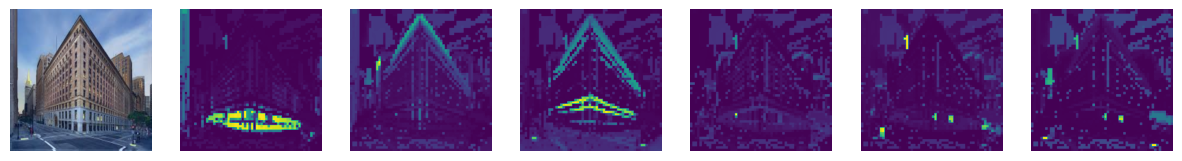

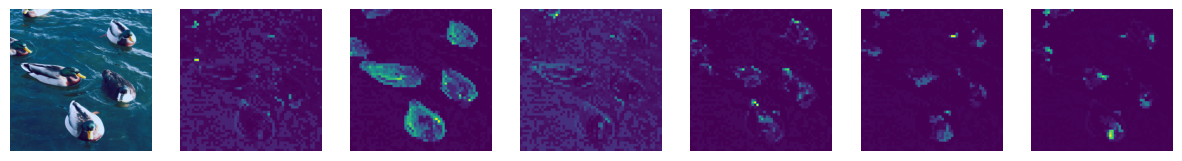

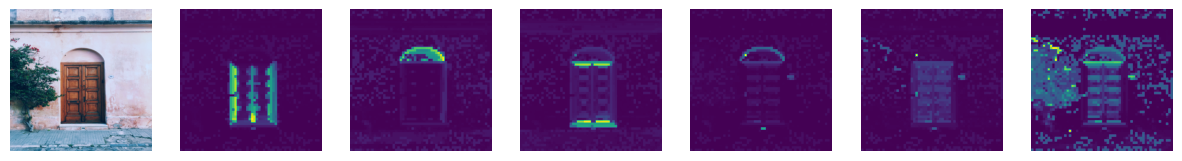

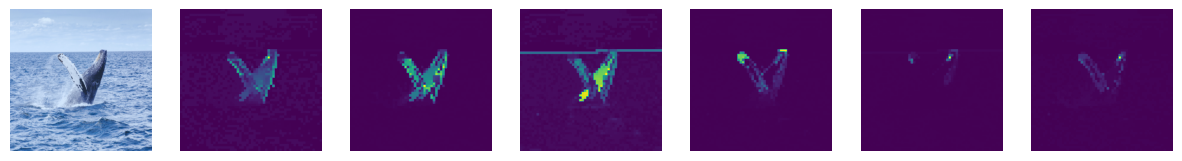

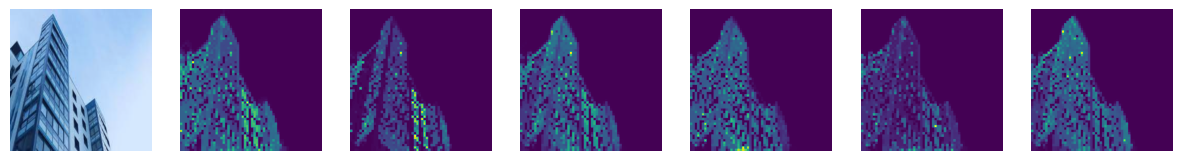

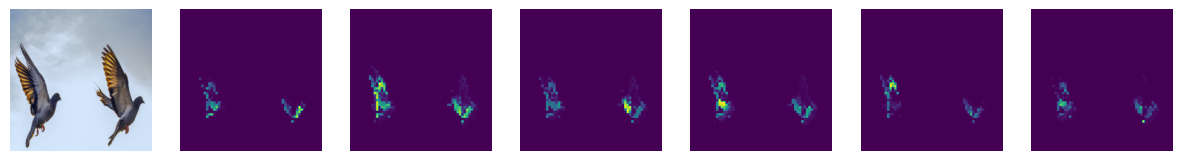

In [ ]:
attentions_list, imgs = collect_attention_maps(img_dir, image_size, patch_size, layer)
for i, img in enumerate(imgs):
  attentions = attentions_list[i]
  nh = attentions.shape[0]
  plt.figure(figsize=(15, 3))
  plt.subplot(1, nh + 1,1)
  plt.imshow(img)
  plt.axis('off')
  for j in range(nh):
    plt.subplot(1, nh + 1, j + 2)
    plt.imshow(attentions[j])
    plt.axis('off')

## Visualizing heads with semantic meanings

We forward a mini-batch of images through a **supervised CRATE**
and examine the attention maps from all the heads in the penultimate layer. We visualize a selection of attention
heads to show that certain heads convey specific semantic meaning, \\
i.e. *head 0 $⇔$ "Legs", head 1$⇔$"Body", head 3$⇔$"Face", head 4$⇔$"Ear"*. \\
For more visualizations, please refer to Figure 7 and Figure 9 in the paper.

In [ ]:
# modify the path if it's not your directory
img_dir = '/content/drive/MyDrive/crate-emergence-notebooks/semantic'
image_size = 480
patch_size = 8
layer = 10

100%|██████████| 6/6 [00:01<00:00,  3.66it/s]


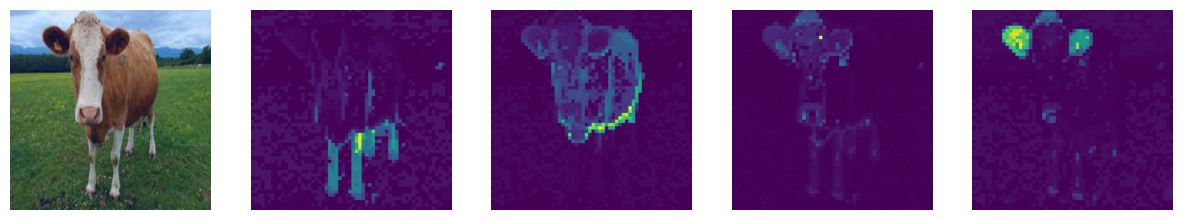

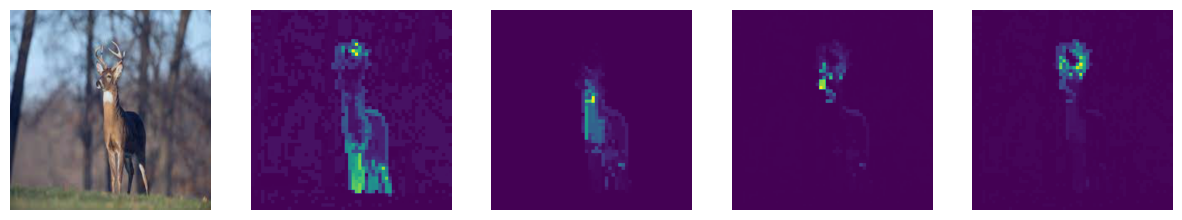

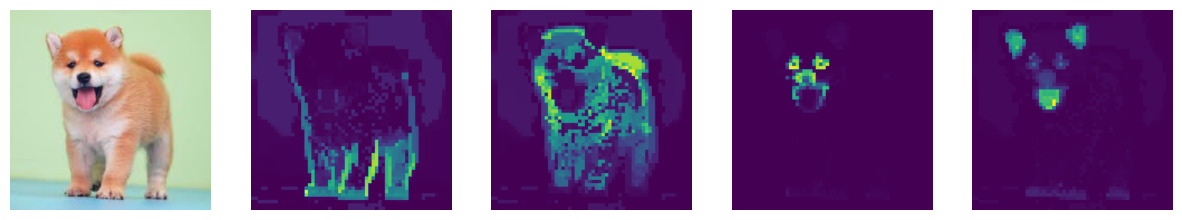

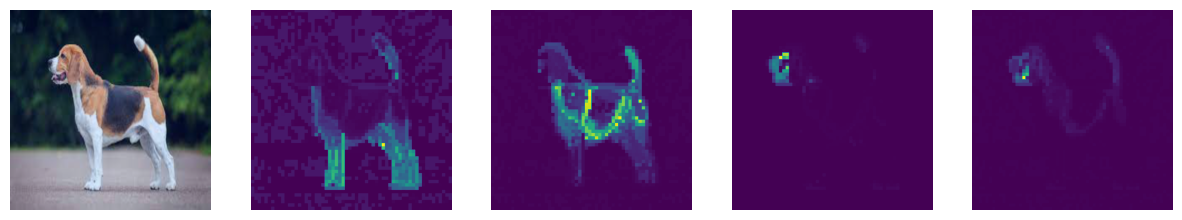

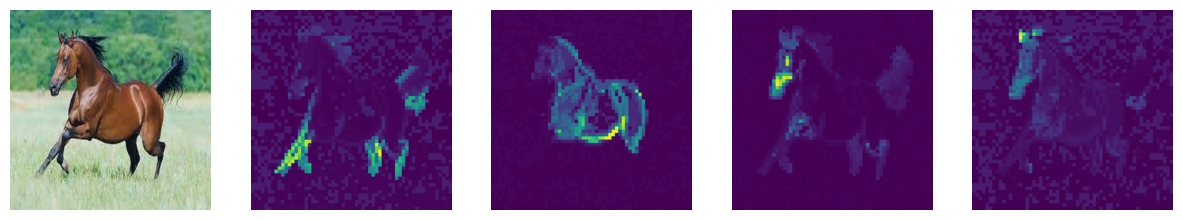

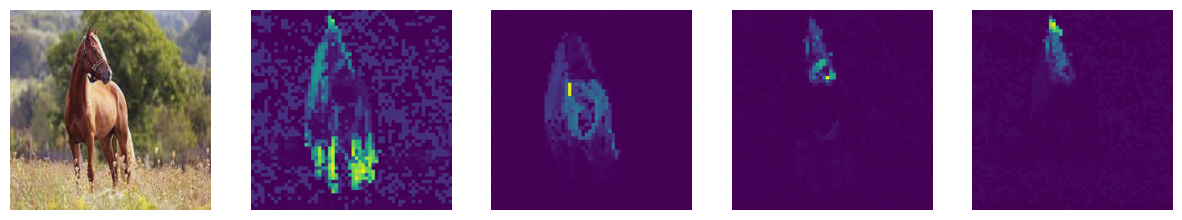

In [ ]:
attentions_list, imgs = collect_attention_maps(img_dir, image_size, patch_size, layer)
# selected heads with semantic meaning
columns = [0, 1, 3, 4]
for i, img in enumerate(imgs):
  attentions = attentions_list[i]
  nh = len(columns)
  plt.figure(figsize=(15, 3))
  plt.subplot(1, nh + 1,1)
  plt.imshow(img)
  plt.axis('off')
  for j, head_idx in enumerate(columns):
    plt.subplot(1, nh + 1, j + 2)
    plt.imshow(attentions[head_idx])
    plt.axis('off')